In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [259]:
import scanpy as sc
import numpy as np
import anndata as ad

from counterfactual_analysis import _normalize_counts


In [220]:
import matplotlib.pyplot as plt


def plot_latents(adata, target_ct, model_name):
    adata.obs_names_make_unique()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # left: counterfactual + control
    left_mask = adata.obs["group"].isin(["counterfactual", "control"])
    sc.pl.umap(
        adata[left_mask].copy(),
        color="group",
        ax=axes[0],
        title=f"{target_ct}: CF vs Control",
        show=False,
        alpha=0.5,
    )

    # right: counterfactual + target
    right_mask = adata.obs["group"].isin(["counterfactual", "target"])
    sc.pl.umap(
        adata[right_mask].copy(),
        color="group",
        ax=axes[1],
        title=f"{target_ct}: CF vs Target",
        show=False,
        alpha=0.5,
    )

    plt.suptitle(f"{model_name} - {target_ct}")
    plt.tight_layout()
    plt.show()

In [5]:
adata = sc.read('/data2/a330d/datasets/crc/raw_zenodo/crc_232.h5ad')

In [8]:
from train_loo import preprocess_adata

adata = preprocess_adata(adata, 
                n_top_genes=2000, 
                n_neighbors=50,
                )

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [10]:
target_ct = 'Endothelial'
adata_ct = adata[adata.obs['coarse_type'] == target_ct].copy()

In [228]:
adata_cellina = sc.read(f'/data2/a330d/datasets/crc/crc_232/{target_ct}/cellina_recon_x.h5ad')
adata_cellina_cf = sc.read(f'/data2/a330d/datasets/crc/crc_232/{target_ct}/cellina_counterfactual_x.h5ad')

In [229]:
adata_cpa = sc.read(f'/data2/a330d/datasets/crc/crc_232/{target_ct}/cpa_recon_x.h5ad')
adata_cpa_cf = sc.read(f'/data2/a330d/datasets/crc/crc_232/{target_ct}/cpa_counterfactual_x.h5ad')

In [230]:
adata_cellina

AnnData object with n_obs × n_vars = 6766 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_0

In [231]:
adata_cellina_cf

AnnData object with n_obs × n_vars = 1772 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_0

In [246]:
adata_cellina.obs['group'] = adata_cellina.obs.typ_clean
adata_cellina_cf.obs['group'] = 'CF'
adata_ct.obs['group'] = adata_cellina.obs.typ_clean

In [248]:
# concat cellina adatas
adata_cellina_all = sc.concat([adata_ct, adata_cellina_cf], axis=0)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [249]:
adata_cellina_all.obs['group'] = adata_cellina_all.obs['group'].replace({'REF': 'control', 'CRC': 'target', 'CF': 'counterfactual'})

In [250]:
adata_cellina_all.obs.group.value_counts()

group
target            4994
control           1772
counterfactual    1772
Name: count, dtype: int64

In [251]:
sc.pp.neighbors(adata_cellina_all)#, use_rep=f'latents')
sc.tl.umap(adata_cellina_all)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


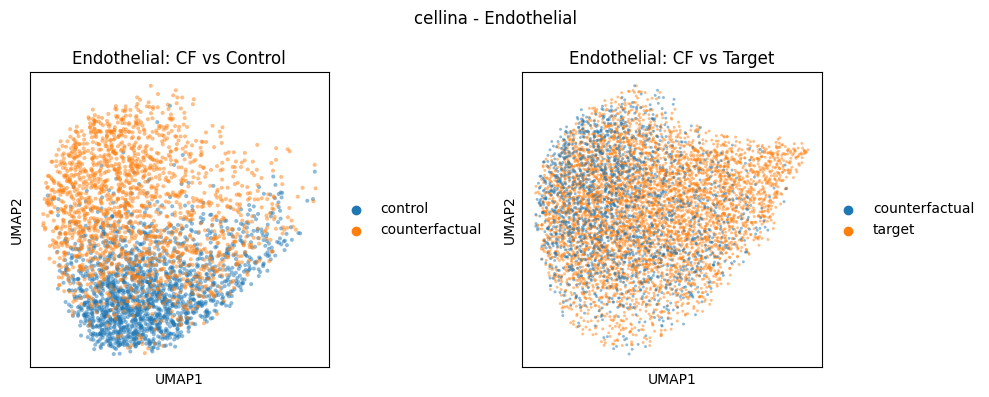

In [237]:
plot_latents(adata_cellina_all, target_ct, 'cellina')

In [265]:
adata_cellina_all.X = _normalize_counts(np.array(adata_cellina_all.X.todense()))

In [267]:
sc.pp.neighbors(adata_cellina_all)#, use_rep=f'latents')
sc.tl.umap(adata_cellina_all)

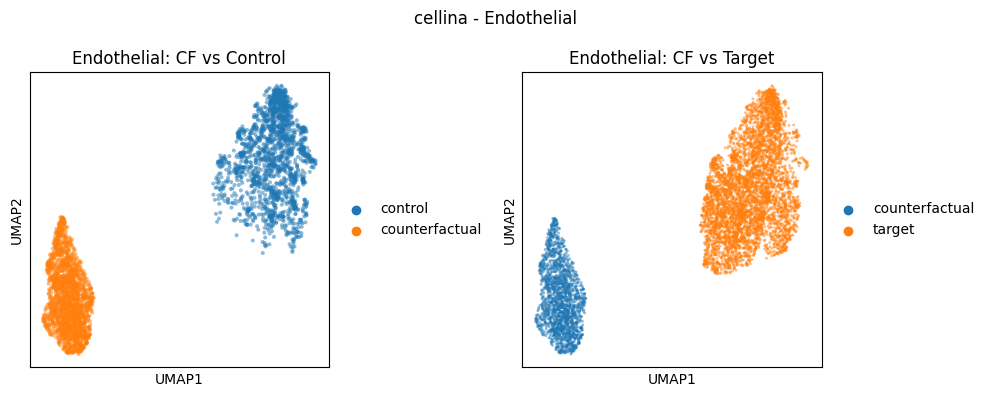

In [268]:
plot_latents(adata_cellina_all, target_ct, 'cellina')

In [238]:
adata_cpa.obs['group'] = adata_cpa.obs.typ_clean
adata_cpa_cf.obs['group'] = 'CF'

In [253]:
# concat cpa adatas
adata_cpa_all = sc.concat([adata_ct, adata_cpa_cf], axis=0)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [254]:
adata_cpa_all.obs['group'] = adata_cpa_all.obs['group'].replace({'REF': 'control', 'CRC': 'target', 'CF': 'counterfactual'})

In [255]:
adata_cpa_all.obs.group.value_counts()

group
target            4994
control           1772
counterfactual    1772
Name: count, dtype: int64

In [256]:
sc.pp.neighbors(adata_cpa_all)#, use_rep=f'latents')
sc.tl.umap(adata_cpa_all)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


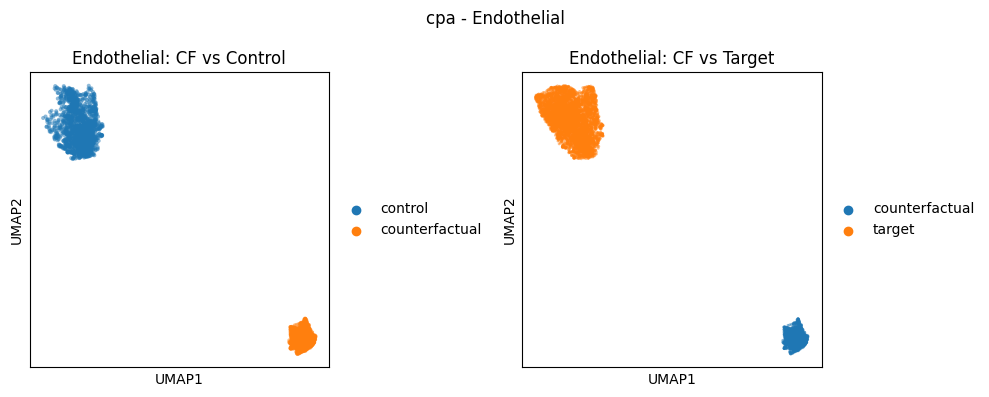

In [257]:
plot_latents(adata_cpa_all, target_ct, 'cpa')

In [269]:
adata_cpa_all.X = _normalize_counts(np.array(adata_cpa_all.X.todense()))

In [270]:
sc.pp.neighbors(adata_cpa_all)#, use_rep=f'latents')
sc.tl.umap(adata_cpa_all)

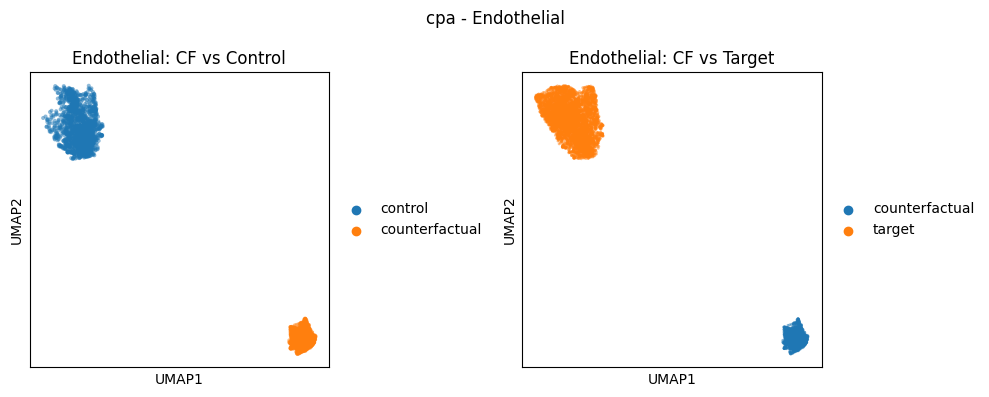

In [271]:
plot_latents(adata_cpa_all, target_ct, 'cpa')

In [297]:
from eval_loo import compute_correlations, get_edistance
use_recon = False

In [304]:
adata_ct.uns['recon_x'] = adata_cellina.X
adata_ct.uns['counterfactual_x'] = adata_cellina_cf.X
# Create 'is_holdout' column and set to True where typ_clean is CRC
adata_ct.obs['is_holdout'] = adata_ct.obs['typ_clean'] == 'CRC'

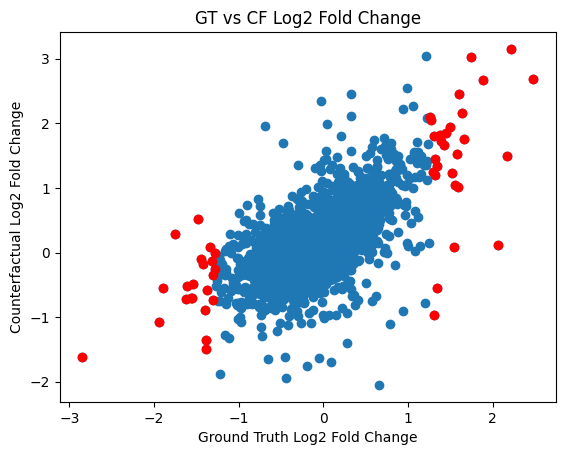

(0.8183240158899769, 0.7621128451380551, 0.32)

In [305]:
pearson, spearman, precision, deg = compute_correlations(adata_ct, target_ct, use_recon=use_recon)
pearson, spearman, precision

In [306]:
n_iter = 5
n_subsample = 200
get_edistance(adata_ct, n_subsample=n_subsample, n_iter=n_iter, use_cf=True, deg=deg, use_latents=False, local=False)

np.float64(14.652851515172973)

In [307]:
from counterfactual_analysis import e_distance, subsample_cells

pop_a = np.array(adata_ct.layers['counts'].todense())
pop_b = adata_ct.uns['recon_x']

pop_a = _normalize_counts(pop_a)
pop_b = _normalize_counts(pop_b)

edists = []
for _ in range(n_iter):
    Xa_s = subsample_cells(pop_a, n_subsample)
    Xb_s = subsample_cells(pop_b, n_subsample)
    edist = e_distance(Xa_s, Xb_s, local=False)
    edists.append(edist)

np.mean(edists)

print(f"Cellina e-distance (recon vs observed) of entire dataset: {np.mean(edists)}")

Cellina e-distance (recon vs observed) of entire dataset: 876.8491957340477


In [308]:
adata_ct.uns['recon_x'] = adata_cpa.X
adata_ct.uns['counterfactual_x'] = adata_cpa_cf.X
# Create 'is_holdout' column and set to True where typ_clean is CRC
adata_ct.obs['is_holdout'] = adata_ct.obs['typ_clean'] == 'CRC'

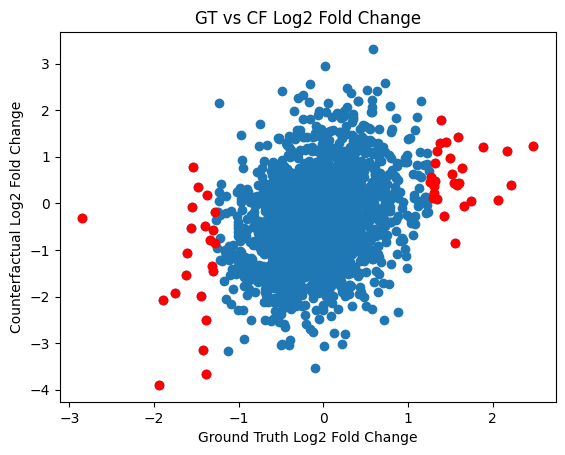

(0.6918778598845549, 0.654453781512605, 0.08)

In [309]:
pearson, spearman, precision, deg = compute_correlations(adata_ct, target_ct, use_recon=use_recon)
pearson, spearman, precision

In [310]:
get_edistance(adata_ct, n_subsample=200, n_iter=5, use_cf=True, deg=deg, use_latents=False, local=False)

np.float64(6.212011950517883)

In [311]:
from counterfactual_analysis import e_distance, subsample_cells

pop_a = np.array(adata_ct.layers['counts'].todense())
pop_b = adata_ct.uns['recon_x']

pop_a = _normalize_counts(pop_a)
pop_b = _normalize_counts(pop_b)

edists = []
for _ in range(n_iter):
    Xa_s = subsample_cells(pop_a, n_subsample)
    Xb_s = subsample_cells(pop_b, n_subsample)
    edist = e_distance(Xa_s, Xb_s, local=False)
    edists.append(edist)

print(f"CPA e-distance (recon vs observed) of entire dataset: {np.mean(edists)}")

CPA e-distance (recon vs observed) of entire dataset: 469.8807581458465


In [185]:
batch_key = 'sid'
labels_key = 'coarse_type'
domains_key = 'typ_clean'

# Cellina default configuration taken from notebooks/conditional_z_mll.ipynb
# These defaults are intended to be imported by scripts/train_loo.py

model_args = {
    # Do not include adata here; train_loo will pass the AnnData when constructing the model
    "n_latent": 64,
    "use_observed_lib_size": True,
    "classifier_lambda": 1.0,
    "discriminator_lambda": 1.0,
    "gene_likelihood": "nb",
}

# Train args mirror the notebook settings. Some keys (like datasplitter external_indexing)
# will be populated at runtime by train_loo if needed.
train_args = {
    "max_epochs": 100,
    "batch_size": 2048, #4096,
    "check_val_every_n_epoch": 1,
    "early_stopping": True,
    "early_stopping_patience": 25,
    "early_stopping_monitor": "validation_loss",
    "enable_checkpointing": True,
    "devices": [0],
}

# Additional plan kwargs sometimes passed to model.train; include a reasonable default
plan_kwargs = {
    "lr": 1e-4,
    "normalize_losses": True,
}

In [186]:
from train_loo import split_indices
train_idx, val_idx, test_idx = split_indices(adata, target_ct, 
                                                 labels_key=labels_key, 
                                                 domains_key=domains_key, 
                                                 seed=0)
splits = (train_idx, val_idx, test_idx)

In [187]:
from cellina import CellinaModel
CellinaModel.setup_anndata(adata, 
                            batch_key=batch_key, 
                            labels_key=labels_key, 
                            domains_key=domains_key, 
                            spatial_obsm_key='spatial_x', 
                            layer='counts')
model = CellinaModel(adata, **model_args)

# Add split info
train_args['datasplitter_kwargs'] = {
            "external_indexing": [splits[0], splits[1], splits[2]],
            }

model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 

Epoch 49/100:  49%|████▉     | 49/100 [02:13<02:19,  2.73s/it, v_num=1, train_loss=321]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 329.733. Signaling Trainer to stop.


In [190]:
library_size = 1e4 # 'latent'
adata_ct.uns['recon_x'] = model.get_normalized_expression(adata_ct, library_size=library_size)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [193]:
adata_ct.uns['latents'] = model.get_latent_representation(adata_ct)

In [194]:
is_tumor_region = adata_ct.obs[domains_key].astype(str).str.contains('CRC', regex=True)
mask_target = is_tumor_region & (adata_ct.obs[labels_key].astype(str) == target_ct)
idx_target = np.where(mask_target.values)[0]
mask_control = (~adata_ct.obs['is_holdout']) & (adata_ct.obs[labels_key] == target_ct)
idx_control = np.where(mask_control.values)[0]

In [199]:
args_gex = {
    "indices": idx_control,
    "neighbour_indices": idx_target,
    "batch_size": 2048,
    "seed": 0,
}
args_gex["adata"] = adata_ct
adata_ct.uns['counterfactual_x'] = model.get_counterfactual_expression(**args_gex)
args_latents = args_gex.copy() # Default gets 'shifted' latents, can set 'z' or 's' here
adata_ct.uns['counterfactual_latents'] = model.get_counterfactual_latents(**args_latents)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [201]:
adata_cellina = ad.AnnData(X=adata_ct.uns['recon_x'], obs=adata_ct.obs.copy(), var=adata_ct.var.copy())
adata_cellina_cf = ad.AnnData(X=adata_ct.uns['counterfactual_x'], obs=adata_ct[idx_control].obs.copy(), var=adata_ct.var.copy())

In [210]:
adata_cellina.obsm['latents'] = adata_ct.uns['latents']
adata_cellina_cf.obsm['latents'] = adata_ct.uns['counterfactual_latents']

In [211]:
adata_cellina.obs['group'] = adata_cellina.obs.typ_clean
adata_cellina_cf.obs['group'] = 'CF'

In [212]:
# concat cellina adatas
adata_cellina_all = sc.concat([adata_cellina, adata_cellina_cf], axis=0)


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [213]:
adata_cellina_all.obs['group'] = adata_cellina_all.obs['group'].replace({'REF': 'control', 'CRC': 'target', 'CF': 'counterfactual'})

In [214]:
adata_cellina_all.obs.group.value_counts()

group
target            4994
control           1772
counterfactual    1772
Name: count, dtype: int64

In [215]:
sc.pp.neighbors(adata_cellina_all, use_rep=f'latents')
sc.tl.umap(adata_cellina_all)

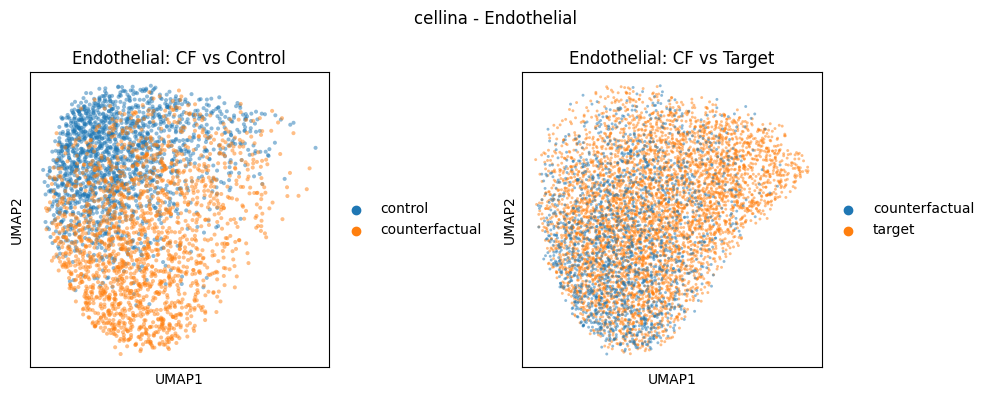

In [221]:
plot_latents(adata_cellina_all, target_ct, 'cellina')

In [222]:
use_recon = False

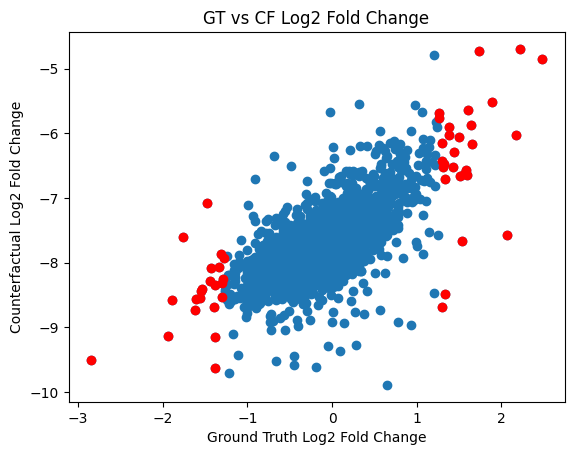

(0.8321214386068654, 0.778343337334934, 0.14)

In [226]:
pearson, spearman, precision, deg = compute_correlations(adata_ct, target_ct, use_recon=use_recon)
pearson, spearman, precision

In [227]:
get_edistance(adata_ct, n_subsample=200, n_iter=5, use_cf=True, deg=None, use_latents=False, local=False)

np.float64(97.38667023061387)